# Clasificacion de Residuos - Red Neuronal Simple

**Proyecto:** Clasificacion Automatica de Residuos mediante Deep Learning  
**Asignatura:** Aprendizaje Profundo  
**Entrega 2:** Modelo de red neuronal simple  

---

## Objetivos del Notebook

1. **Cargar** el dataset preprocesado y verificar su consistencia.
2. **Dividir** el conjunto en train/validacion/test de forma estratificada.
3. **Definir** un modelo CNN minimo (capas convolucionales = numero de clases).
4. **Entrenar** el modelo y mostrar curvas de entrenamiento.
5. **Evaluar** el rendimiento en train, validacion y test.
6. **Reportar** el numero de parametros del modelo.

In [1]:
# ========================================
# 1. IMPORTS Y CONFIGURACION
# ========================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, callbacks

from sklearn.metrics import (
    accuracy_score,
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Agregar ruta del proyecto al path (carpeta padre de notebooks)
sys.path.insert(0, '..')

# Importar funciones de utilidad
from src.utils import initialize_project

# Verificar versión de TensorFlow
print(f"TensorFlow versión: {tf.__version__}")

2026-03-09 15:37:43.074567: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-09 15:37:43.074773: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-09 15:37:43.101637: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-09 15:37:43.732825: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

TensorFlow versión: 2.20.0


## 2. Carga de datos y configuración

Se carga automáticamente el dataset desde el archivo .npz y se realiza la división estratificada.

In [2]:
# ========================================
# 2. CARGA DE DATOS Y CONFIGURACION
# ========================================

X_train, y_train, X_val, y_val, X_test, y_test, class_names = initialize_project()

Ejecutando en local

Cargando datos desde: /home/anuega/archivos/notebooks/../data/processed/trashnet_224x224.npz
  X.shape: (2527, 224, 224, 3)
  y.shape: (2527,)
  Clases: cardboard, glass, metal, paper, plastic, trash

División estratificada (seed=44):
  Train: 1768 imágenes (70%)
  Val:   379 imágenes (15%)
  Test:  380 imágenes (15%)


## 3. Definición del modelo

El modelo se define en `models/simple_cnn.py` y se carga desde el notebook.

La red es una **CNN mínima para clasificación multiclase**. Incluye una única capa Conv2D con tantos filtros como clases, de modo que cada filtro aprende un mapa de activación asociado a patrones discriminativos de una clase. La capa GlobalAveragePooling2D promedia cada mapa espacialmente, reduciéndolo a un único valor por clase. Finalmente, una capa densa con activación softmax produce una distribución de probabilidad sobre las clases.

En el entrenamiento se **minimiza la sparse categorical cross-entropy**, adecuada cuando las etiquetas están codificadas como enteros. Esta función mide la discrepancia entre la distribución predicha por la softmax y la clase verdadera. La optimización se realiza con Adam (learning rate 1e-3).

In [3]:
# ── CAMBIAR ESTAS DOS LÍNEAS SEGÚN EL MODELO ─────────────────────────────
try:
    from models.A1_simple_cnn import build_simple_cnn as build_model
except ModuleNotFoundError:
    raise ImportError("El módulo 'models.A1_simple_cnn' no se encuentra. Verifica la ruta o el nombre del archivo.")

# Definir un nombre para el modelo
MODEL_NAME = "A1_SimpleCNN"

model = build_model(input_shape=(224, 224, 3), num_classes=6)
model.summary()

/home/anuega/miniconda3/envs/gcd/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1773067068.685846 3379022 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773067068.692492 3379022 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "A1_SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 6)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210 (840.00 B)

 Trainable params: 210 (840.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento

Se entrena el modelo y se muestran las curvas de loss y accuracy.

In [ ]:
MODEL_NAME = 'A1_SimpleCNN'   # para guardar checkpoints y logs

# ── Learning Rate Scheduler ──────────────────────────────────────────────────
# Estrategia: Cosine Annealing | comienza alto (0.01) y decae suavemente a ~0
num_train_samples = len(X_train)
batch_size = 32 
steps_per_epoch = num_train_samples // batch_size
total_steps = steps_per_epoch * 700 

lr_scheduler = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,  
    decay_steps=total_steps,
    alpha=1e-2 
)

# ── Callbacks ───────────────────────────────────────────────────────────────
cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=f'best_{MODEL_NAME}_phase1.keras',
    monitor='val_loss', save_best_only=True, verbose=0)

# ── Compilar ─────────────────────────────────────────────────────────────────
# Adam con CosineDecay scheduler (baja suavemente de 0.01 a ~0)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_scheduler),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ── Entrenamiento Fase 1 ─────────────────────────────────────────────────────
history_p1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=700,
    callbacks=[cb_checkpoint],
    verbose=1,
    batch_size=batch_size
)

Epoch 1/700
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2517 - loss: 1.7561 - val_accuracy: 0.2348 - val_loss: 1.7472
Epoch 2/700
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2376 - loss: 1.7398 - val_accuracy: 0.2348 - val_loss: 1.7363
Epoch 3/700
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2376 - loss: 1.7305 - val_accuracy: 0.2348 - val_loss: 1.7286
Epoch 4/700
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2364 - loss: 1.7238 - val_accuracy: 0.2348 - val_loss: 1.7230
Epoch 5/700
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2364 - loss: 1.7189 - val_accuracy: 0.2348 - val_loss: 1.7189
Epoch 6/700
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2370 - loss: 1.7151 - val_accuracy: 0.2348 - val_loss: 1.7157
Epoch 7/700
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2387 - loss: 1.7122 - val_accuracy: 0.2348 - val_loss: 1.7131
Epoch 8/700
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2398 - loss: 1.7097 - val_accuracy: 0.

## 5. Evaluación en particiones

Se evalúa el modelo en train, validación y test con métricas estándar.

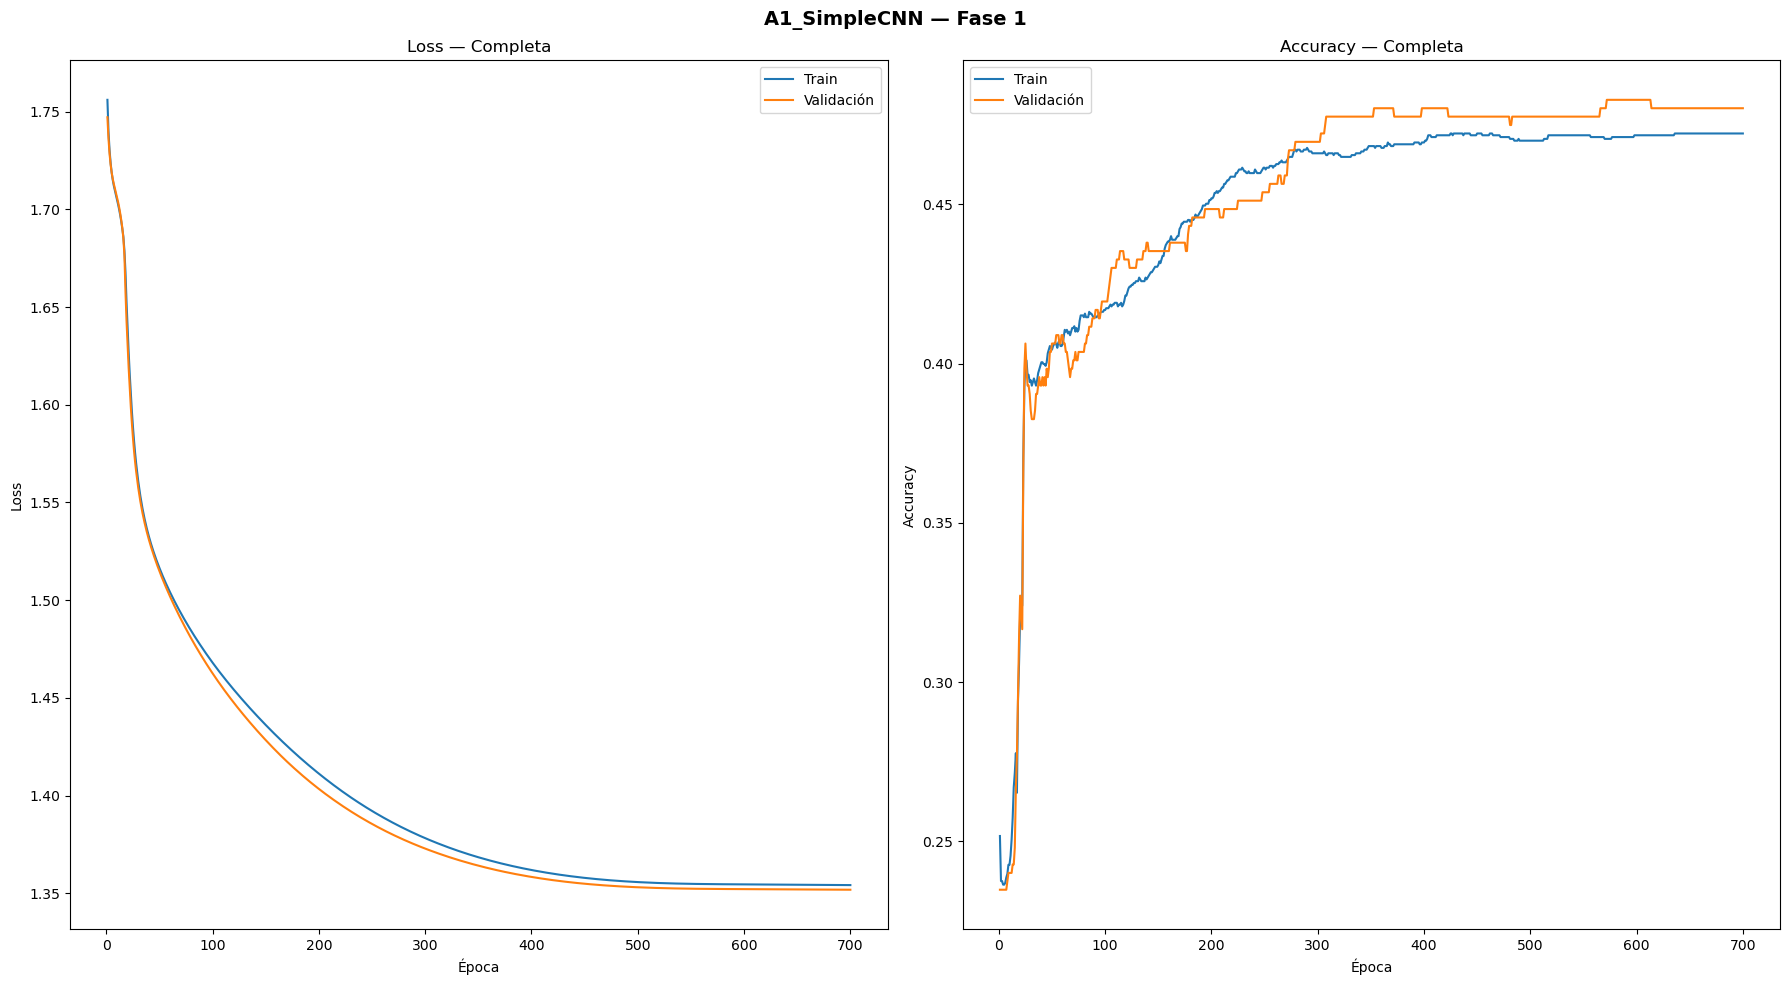

In [5]:
def plot_training(history, title='', phase=1):
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    epochs   = range(1, len(loss) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))
    fig.suptitle(f'{title} — Fase {phase}', fontsize=14, fontweight='bold')

    # ── Fila 1: Loss ─────────────────────────────────────────────────────────
    # 1a) Curva completa
    axes[0].plot(epochs, loss,     label='Train')
    axes[0].plot(epochs, val_loss, label='Validación')
    axes[0].set_title('Loss — Completa')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend()

    # ── Fila 2: Accuracy ─────────────────────────────────────────────────────
    axes[1].plot(epochs, acc,     label='Train')
    axes[1].plot(epochs, val_acc, label='Validación')
    axes[1].set_title('Accuracy — Completa')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'curvas_{MODEL_NAME}_fase{phase}.png', dpi=150)
    plt.show()

plot_training(history_p1, title=MODEL_NAME, phase=1)

### 5.1. Visualización de métricas

Comparación visual de las métricas entre las particiones para identificar posible overfitting o underfitting.

In [9]:
def evaluate_split(model, X, y, split_name):
    """Calcula y muestra Accuracy, Precision, Recall y F1-macro."""
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y, y_pred, average='macro', zero_division=0)
    print(f'[{split_name:>5}]  Acc={acc:.4f}  Prec={prec:.4f}  '
          f'Rec={rec:.4f}  F1={f1:.4f}')
    return {'split': split_name, 'acc': acc,
            'prec': prec, 'rec': rec, 'f1': f1, 'y_pred': y_pred}

print('=' * 60)
print(f'Modelo: {MODEL_NAME}')
print('=' * 60)
res_train = evaluate_split(model, X_train, y_train, 'Train')
res_val   = evaluate_split(model, X_val,   y_val,   'Val')
res_test  = evaluate_split(model, X_test,  y_test,  'Test')
print('=' * 60)

Modelo: A1_SimpleCNN
[Train]  Acc=0.4717  Prec=0.4138  Rec=0.4100  F1=0.3937
[  Val]  Acc=0.4802  Prec=0.4406  Rec=0.4138  F1=0.4030
[ Test]  Acc=0.4921  Prec=0.4257  Rec=0.4326  F1=0.4150


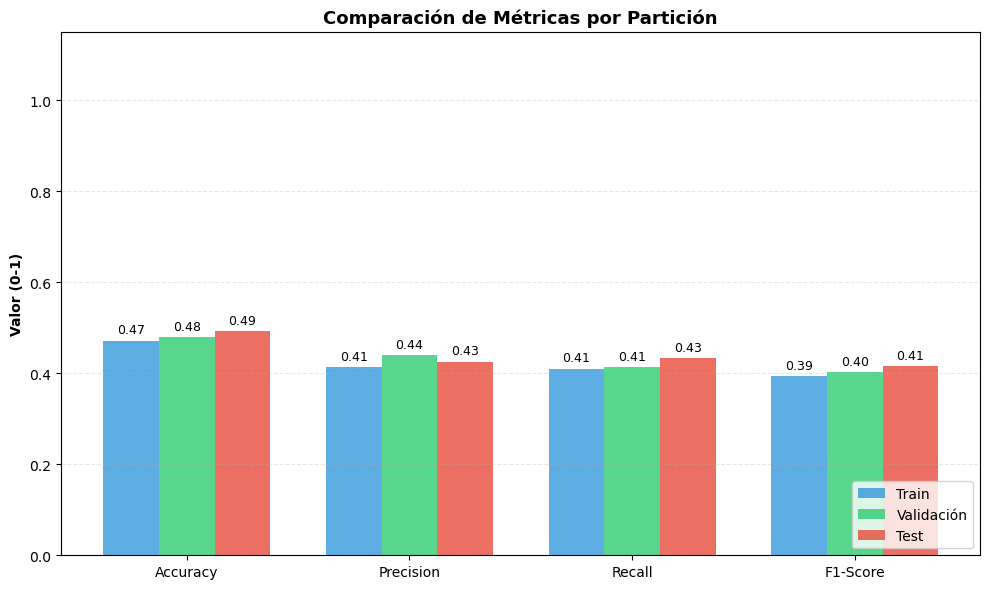

In [10]:
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_names))
width = 0.25

# Obtener resultados de las métricas
results_train = [res_train['acc'], res_train['prec'], res_train['rec'], res_train['f1']]
results_val = [res_val['acc'], res_val['prec'], res_val['rec'], res_val['f1']]
results_test = [res_test['acc'], res_test['prec'], res_test['rec'], res_test['f1']]

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width, results_train, width, label='Train', color='#3498db', alpha=0.8)
rects2 = ax.bar(x, results_val, width, label='Validación', color='#2ecc71', alpha=0.8)
rects3 = ax.bar(x + width, results_test, width, label='Test', color='#e74c3c', alpha=0.8)

# Añadir etiquetas de valor sobre las barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

ax.set_ylabel('Valor (0-1)', fontweight='bold')
ax.set_title('Comparación de Métricas por Partición', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

### 5.2. Matrices de confusión

Visualización de las matrices de confusión para cada partición (train, validación y test) para identificar patrones de error.

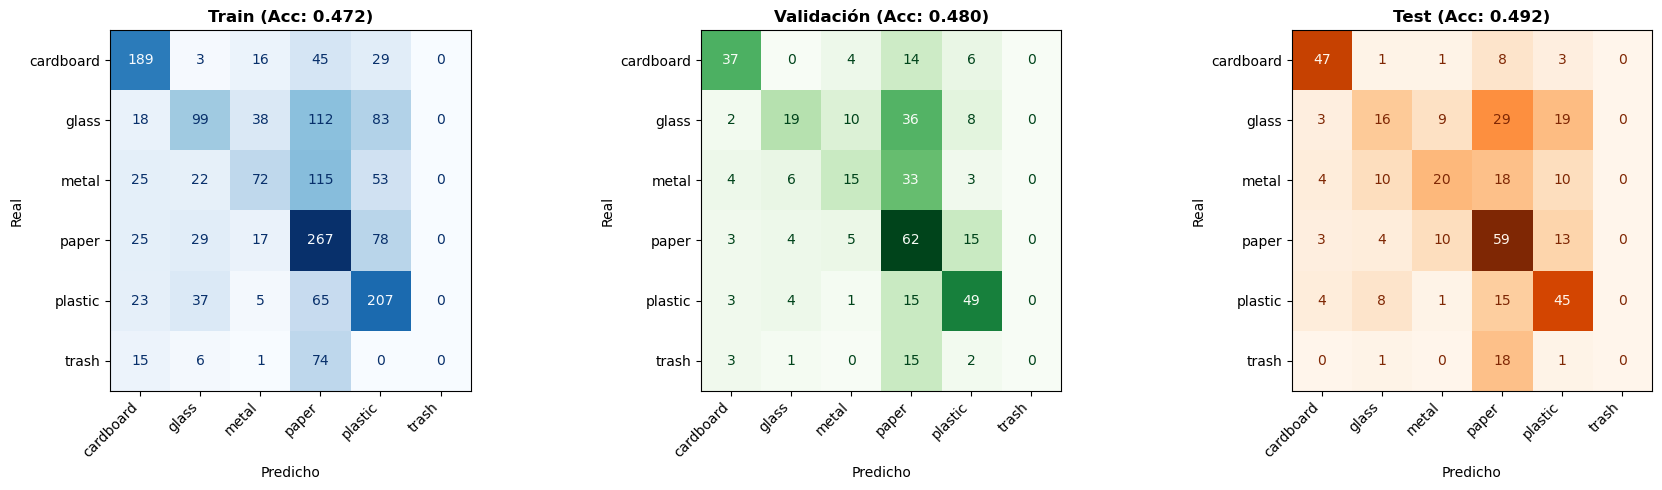

In [22]:
# Matrices de confusión para Train, Val y Test
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicciones
y_pred_train = res_train['y_pred']
y_pred_val = res_val['y_pred']
y_pred_test = res_test['y_pred']

# Train
cm_train = confusion_matrix(y_train, y_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=class_names)
disp_train.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Train (Acc: {results_train[0]:.3f})", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicho", fontsize=10)
axes[0].set_ylabel("Real", fontsize=10)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Validación
cm_val = confusion_matrix(y_val, y_pred_val)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=class_names)
disp_val.plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"Validación (Acc: {results_val[0]:.3f})", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Predicho", fontsize=10)
axes[1].set_ylabel("Real", fontsize=10)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Test
cm_test = confusion_matrix(y_test, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp_test.plot(ax=axes[2], cmap="Oranges", colorbar=False)
axes[2].set_title(f"Test (Acc: {results_test[0]:.3f})", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Predicho", fontsize=10)
axes[2].set_ylabel("Real", fontsize=10)
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 6. Interpretabilidad
 A diferencia del SVM que usa márgenes geométricos, en una Red Neuronal analizamos la **probabilidad softmax** 
 - **Alta confianza:** La probabilidad de la clase ganadora es cercana a 1.0 (ej: 0.99 vs 0.01).
 - **Incertidumbre (Duda):** La probabilidad se reparte entre varias clases.

 Aquí buscamos las imágenes con el menor **"Confidence Gap"**: la diferencia entre la probabilidad de la clase ganadora y la de la segunda mejor opción.

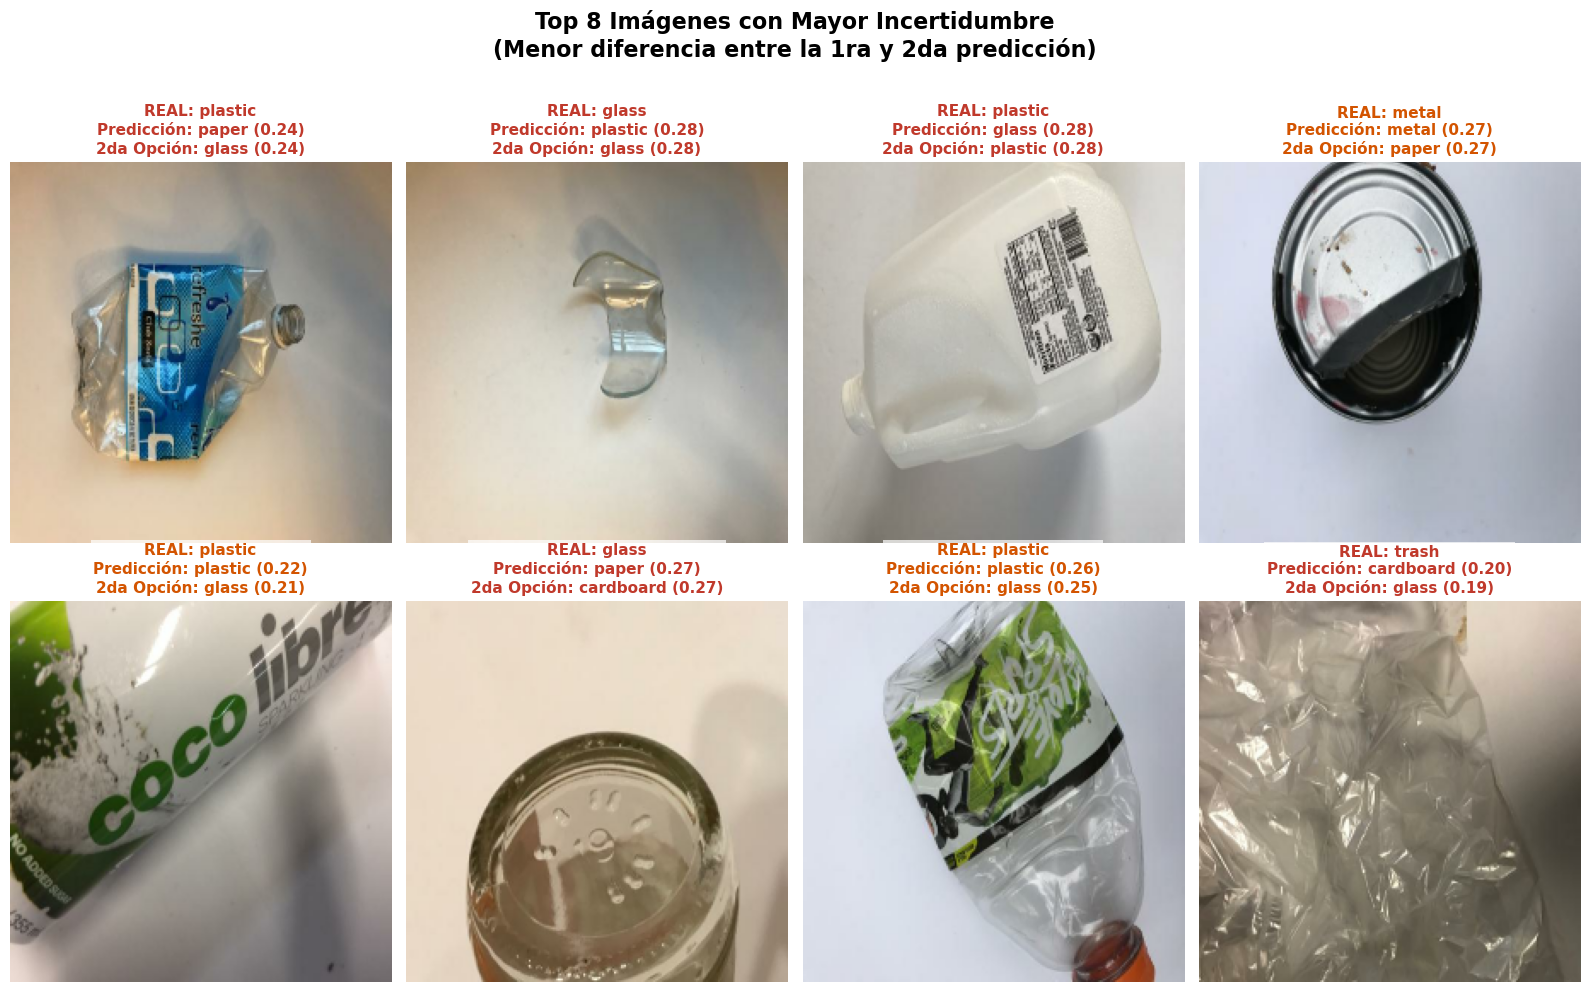

In [ ]:
# 1. Obtener probabilidades
probs_test = model.predict(X_test, verbose=0)

# 2. Obtener los índices de las clases ordenados por probabilidad
top_indices_sorted = np.argsort(probs_test, axis=1)

# 3. Calcular la diferencia (gap) entre la 1ra y 2da opción
sorted_probs = np.sort(probs_test, axis=1)
uncertainty_gap = sorted_probs[:, -1] - sorted_probs[:, -2]

# 4. Seleccionar los índices de las imágenes con mayor duda (menor gap)
k = 8
most_uncertain_idx = np.argsort(uncertainty_gap)[:k]

# 5. Visualización
cols = 4
rows = int(np.ceil(k / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows)) # Un poco más alto para el texto
axes = np.array(axes).reshape(-1)

# --- TÍTULO GENERAL DE LA FIGURA ---
plt.suptitle(f"Top {k} Imágenes con Mayor Incertidumbre\n(Menor diferencia entre la 1ra y 2da predicción)", 
             fontsize=16, fontweight='bold', y=1.02)

for i, (ax, idx) in enumerate(zip(axes, most_uncertain_idx)):
    img = X_test[idx].astype(np.uint8)
    
    # Índices reales y predichos
    true_idx = y_test[idx]
    pred_idx_1 = top_indices_sorted[idx, -1] # La más alta
    pred_idx_2 = top_indices_sorted[idx, -2] # La segunda más alta
    
    # Nombres
    true_lbl = class_names[true_idx]
    pred_lbl_1 = class_names[pred_idx_1]
    pred_lbl_2 = class_names[pred_idx_2]
    
    # Probabilidades
    prob_1 = sorted_probs[idx, -1]
    prob_2 = sorted_probs[idx, -2]
    
    # Color: Rojo si falló, Naranja si acertó pero dudando
    color_text = '#c0392b' if true_idx != pred_idx_1 else '#d35400'
    
    ax.imshow(img)
    
    # --- TÍTULO DETALLADO POR IMAGEN ---
    info_text = (
        f"REAL: {true_lbl}\n"
        f"Predicción: {pred_lbl_1} ({prob_1:.2f})\n"
        f"2da Opción: {pred_lbl_2} ({prob_2:.2f})"
    )
    
    ax.set_title(info_text, fontsize=11, fontweight='bold', color=color_text,  bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
    ax.axis('off')

# Apagar ejes vacíos
for ax in axes[k:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### 6.2. Visualización de Errores en Test

Muestra ejemplos concretos de imágenes del conjunto de Test que el modelo clasificó incorrectamente para entender las debilidades del clasificador.

Resumen de errores en Test:
  Total muestras: 380
  Errores: 221 (58.16%)


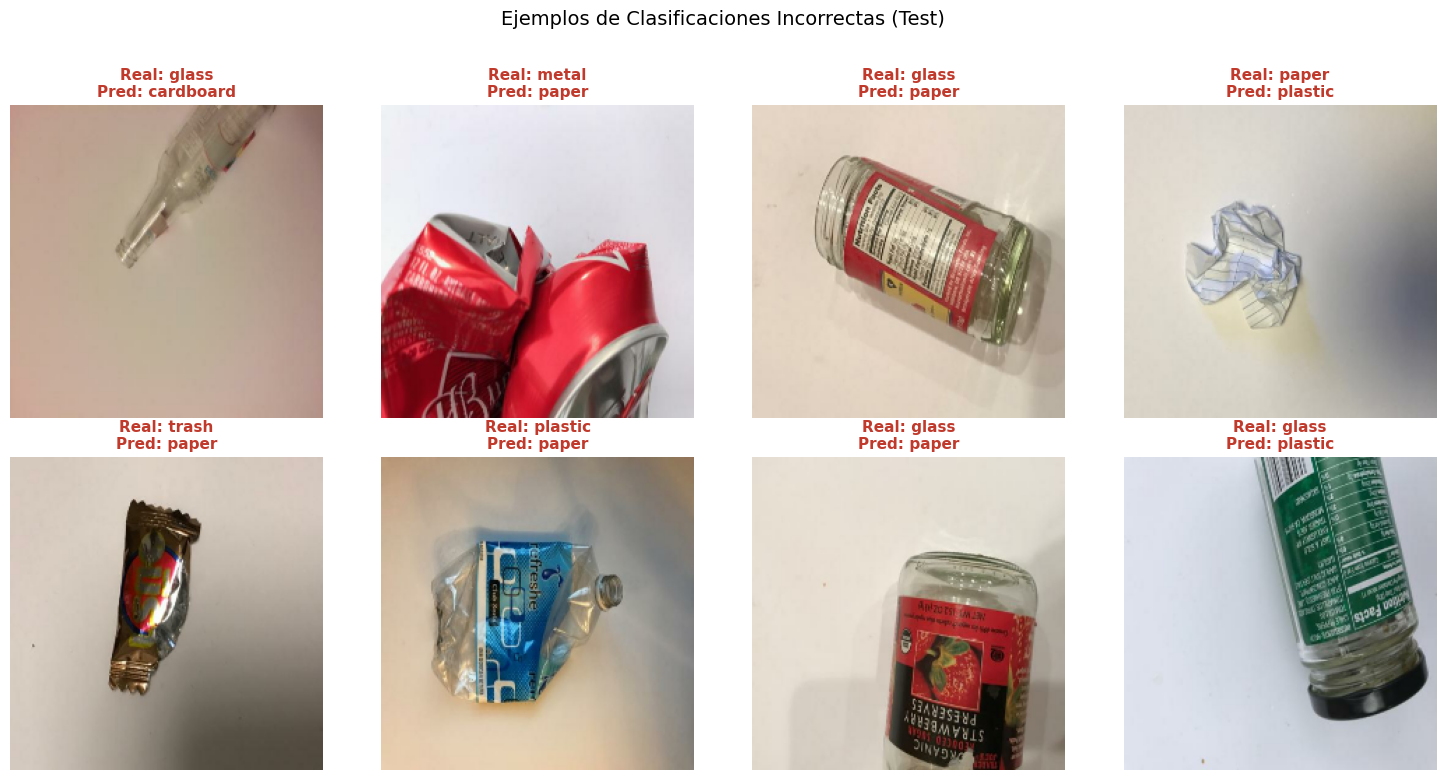


Confusiones más frecuentes (Real -> Predicho):
  glass        -> plastic      : 28 veces
  glass        -> paper        : 26 veces
  metal        -> paper        : 25 veces
  paper        -> plastic      : 18 veces
  paper        -> glass        : 17 veces


In [ ]:
# =======================================
# 6.2. VISUALIZACION DE ERRORES
# ========================================

# Identificar índices de errores
mis_idx = np.where(y_pred_test != y_test)[0]
total_test = len(y_test)
num_errors = len(mis_idx)

print(f"Resumen de errores en Test:")
print(f"  Total muestras: {total_test}")
print(f"  Errores: {num_errors} ({num_errors/total_test*100:.2f}%)")

if num_errors > 0:
    # Mostrar hasta 8 ejemplos de error aleatorios
    show_n = min(8, num_errors)
    
    np.random.seed(42) 
    chosen_errors = np.random.choice(mis_idx, size=show_n, replace=False)
    
    cols = 4
    rows = int(np.ceil(show_n / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.8 * rows))
    axes = np.array(axes).reshape(-1)
    
    for i, (ax, idx) in enumerate(zip(axes, chosen_errors)):
        img = X_test[idx].astype(np.uint8)
        true_lbl = class_names[y_test[idx]]
        pred_lbl = class_names[y_pred_test[idx]]
        
        ax.imshow(img)
        # Título en rojo indicando el error
        ax.set_title(f"Real: {true_lbl}\nPred: {pred_lbl}", 
                     color='#c0392b', fontsize=11, fontweight='bold')
        ax.axis('off')
        
    # Ocultar ejes vacíos si hay menos de 8 errores
    for ax in axes[show_n:]:
        ax.axis('off')
        
    plt.suptitle("Ejemplos de Clasificaciones Incorrectas (Test)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Mostrar pares de confusión más frecuentes
    print("\nConfusiones más frecuentes (Real -> Predicho):")
    error_pairs = [(class_names[y_test[i]], class_names[y_pred_test[i]]) for i in mis_idx]
    from collections import Counter
    most_common = Counter(error_pairs).most_common(5)
    
    for (real, pred), count in most_common:
        print(f"  {real:12} -> {pred:12} : {count} veces")

## 7. Número de parámetros del modelo

Se reporta el número total de parámetros entrenables del modelo.

In [ ]:
num_params = model.count_params()
print(f'Número total de parámetros: {num_params:,}')

Número total de parámetros: 210


## 8. Resumen final

Resumen compacto con las métricas del modelo.

In [ ]:
print('\nRESUMEN FINAL (CNN SIMPLE)')
print(f'  Train -> Acc: {results_train[0]:.4f}, F1: {results_train[3]:.4f}')
print(f'  Val   -> Acc: {results_val[0]:.4f}, F1: {results_val[3]:.4f}')
print(f'  Test  -> Acc: {results_test[0]:.4f}, F1: {results_test[3]:.4f}')
print(f'  Params: {num_params:,}')


RESUMEN FINAL (CNN SIMPLE)
  Train -> Acc: 0.4129, F1: 0.3399
  Val   -> Acc: 0.4644, F1: 0.3981
  Test  -> Acc: 0.4184, F1: 0.3487
  Params: 210


## 9. Conclusiones

Al entrenar el modelo **A1_SimpleCNN** (arquitectura mínima), se observa un comportamiento coherente con lo esperado para una red de baja capacidad:

- Las métricas en train, validación y test permiten confirmar que el modelo **aprende patrones básicos**, pero su poder de discriminación entre clases similares es limitado.
- El entrenamiento con muchas épocas y scheduler (CosineDecay) ayuda a estabilizar la optimización, pero **no compensa por completo** la simplicidad de la arquitectura.
- Los resultados globales pueden considerarse **moderados**, algo esperable en este punto del proyecto: el modelo sirve como línea base, pero todavía no captura suficiente complejidad visual del problema.
- La brecha entre particiones y los errores observados en matriz de confusión sugieren confusiones entre clases con apariencia parecida (texturas/colores cercanos).

En síntesis: usando el modelo más simple obtenemos resultados funcionales pero discretos; esto valida la necesidad de avanzar a arquitecturas CNN más profundas o con mejor capacidad de extracción de características para mejorar el rendimiento en test.